In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv")
df.head(10)

cols_with_zeros = ["Glucose", "BloodPressure", "BMI"]
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.fillna(df.median(numeric_only=True), inplace=True)

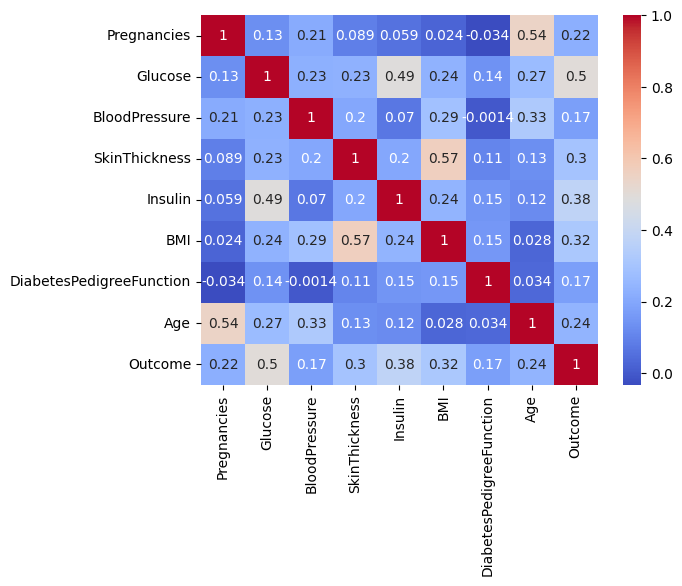

In [3]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [4]:
x = df.drop(columns=["Outcome"]).values
y = df["Outcome"].values.reshape(-1,1)

# print(x,y)

m = len(x)
np.random.seed(42)
indices = np.random.permutation(m)
split = int(0.8 * m)
train_idx, test_idx = indices[:split], indices[split:]

x_train, x_test = x[train_idx], x[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

## as features are not scaled uniformly, we need to scale them accordingly, by making all values converted to [-1,1]

$$
X_{\text{new}}=\frac{X-\mu }{\sigma }
$$
$$
standardisation
$$

In [5]:
mu    = x_train.mean(axis=0)
sigma = x_train.std(axis=0)
x_train = (x_train - mu) / sigma
x_test  = (x_test  - mu) / sigma   # same mu/sigma, not test's own


def polynomial_features(x, degree=2):
    features = [x]
    for d in range(2, degree + 1):
        features.append(x ** d)
    for i in range(x.shape[1]):
        for j in range(i+1, x.shape[1]):
            features.append((x[:, i] * x[:, j]).reshape(-1, 1))
    return np.hstack(features)

x_train = polynomial_features(x_train, degree=2)
x_test  = polynomial_features(x_test,  degree=2)

mu2    = x_train.mean(axis=0)
sigma2 = x_train.std(axis=0)
x_train = (x_train - mu2) / sigma2
x_test  = (x_test  - mu2) / sigma2

In [6]:
m_train = len(x_train)
m_test  = len(x_test)
x_train = np.hstack([np.ones((m_train, 1)), x_train])
x_test  = np.hstack([np.ones((m_test,  1)), x_test])

w = np.zeros((x_train.shape[1], 1))


def sigmoid(z):
    return 1/(1+np.exp(-z))

def cost_func(x,y,w):
    m = len(y)
    
    h = sigmoid(x @ w)
    h = np.clip(h, 1e-15, 1 - 1e-15)

    return (-1/m)*(np.sum(
        (y * np.log(h)) + ((1-y) * np.log(1-h))
    ))

def gradient_descent(x,y,w,alpha,epochs,tol = 1e-7):
    m = len(y)
    cost_history = []

    for i in range(epochs):
        h = sigmoid(x @ w)
        dj_dw = (1/m) * (x.T @ (h-y))

        w = w - alpha * dj_dw
        
        cost_history.append(cost_func(x, y, w))

        if i % 1000 == 0:
            print(f"Iter {i}: cost = {cost_history[-1]}")
            if(i>3000 and abs(cost_history[-1] - cost_history[-2]) < tol):
                print(f"Iter {i}: cost = {cost_history[-1]}")
                break
                

    return w,cost_history

In [7]:
# training
w = np.zeros((x_train.shape[1], 1))
w, cost_history = gradient_descent(x_train, y_train, w, 0.01, 100000)

Iter 0: cost = 0.6909290723726504
Iter 1000: cost = 0.40595658961822395
Iter 2000: cost = 0.38387518102715323
Iter 3000: cost = 0.37536496405334646
Iter 4000: cost = 0.3709002799365658
Iter 5000: cost = 0.3681608186896352
Iter 6000: cost = 0.3662985139300352
Iter 7000: cost = 0.3649379938282376
Iter 8000: cost = 0.36389173842589584
Iter 9000: cost = 0.3630571952622351
Iter 10000: cost = 0.3623739571674438
Iter 11000: cost = 0.3618041193281511
Iter 12000: cost = 0.3613225600606687
Iter 13000: cost = 0.36091181658312615
Iter 14000: cost = 0.3605592293430442
Iter 15000: cost = 0.3602552711638771
Iter 16000: cost = 0.3599925284433207
Iter 17000: cost = 0.3597650594199235
Iter 18000: cost = 0.3595679803809924
Iter 19000: cost = 0.3593971944595437
Iter 20000: cost = 0.3592492113933741
Iter 21000: cost = 0.35912102556085657
Iter 22000: cost = 0.359010031092905
Iter 23000: cost = 0.3589139603244408
Iter 23000: cost = 0.3589139603244408


In [8]:
# accuracy
preds    = sigmoid(x_test @ w) >= 0.40
accuracy = np.mean(preds == y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8701


In [9]:
print(f"Train accuracy: {np.mean((sigmoid(x_train @ w) >= 0.4) == y_train):.4f}")
print(f"Test accuracy:  {np.mean((sigmoid(x_test  @ w) >= 0.4) == y_test):.4f}")

Train accuracy: 0.8550
Test accuracy:  0.8701


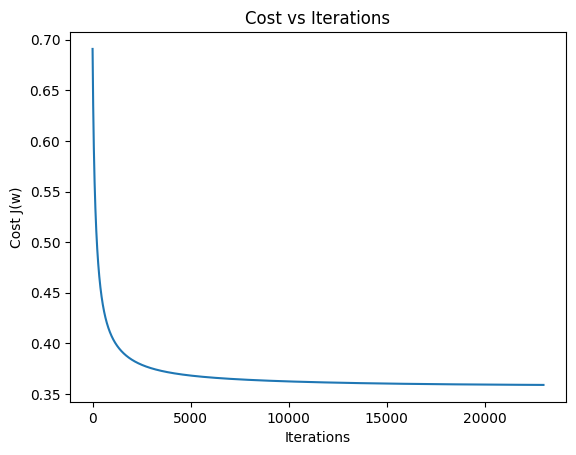

In [10]:
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost J(w)")
plt.show()

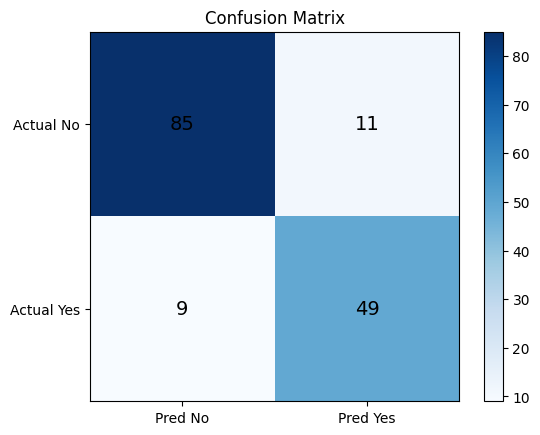

In [11]:
preds = (sigmoid(x_test @ w) >= 0.40).astype(int)
tp = np.sum((preds == 1) & (y_test == 1))
tn = np.sum((preds == 0) & (y_test == 0))
fp = np.sum((preds == 1) & (y_test == 0))
fn = np.sum((preds == 0) & (y_test == 1))
cm = np.array([[tn, fp], [fn, tp]])

plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0,1], ["Pred No", "Pred Yes"])
plt.yticks([0,1], ["Actual No", "Actual Yes"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", fontsize=14)
plt.title("Confusion Matrix")
plt.show()

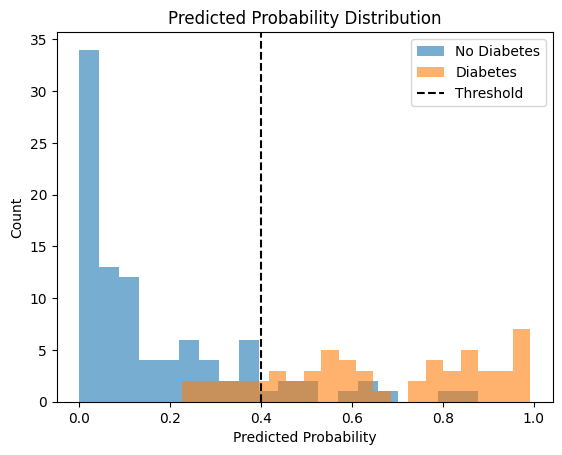

In [12]:
probs = sigmoid(x_test @ w).flatten()
plt.hist(probs[y_test.flatten()==0], bins=20, alpha=0.6, label="No Diabetes")
plt.hist(probs[y_test.flatten()==1], bins=20, alpha=0.6, label="Diabetes")
plt.axvline(0.40, color="black", linestyle="--", label="Threshold")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()

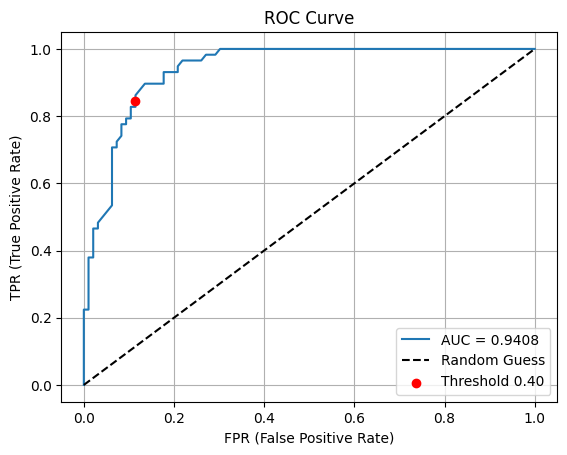

In [13]:
probs = sigmoid(x_test @ w).flatten()
thresholds = np.linspace(0, 1, 200)
tprs, fprs = [], []
for t in thresholds:
    p = (probs >= t).astype(int)
    tprs.append(np.sum((p==1)&(y_test.flatten()==1)) / np.sum(y_test==1))
    fprs.append(np.sum((p==1)&(y_test.flatten()==0)) / np.sum(y_test==0))

# AUC using trapezoidal rule
auc = -np.trapezoid(tprs, fprs)

plt.plot(fprs, tprs, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],"k--", label="Random Guess")
plt.scatter([11/96], [49/58], color="red", zorder=5, label="Threshold 0.40")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()